In [24]:
import sys
sys.path.append('/home/pulpo/Documents/quantitative-trading')
from src.quanttrading.analysis import calculate_stats, detect_outliers, get_percentiles
from backtesting import Backtest, Strategy
from pandas.plotting import autocorrelation_plot
from src.quanttrading.data import prepare_data
import matplotlib.pyplot as plt
import pandas as pd

In [25]:
# DOWNLOAD DATA
df_eurusd = prepare_data('EURUSD=x', '1y', '4h')

df_eurusd.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Return
Datetime,,,,,,
2026-05-01 03:00:00+00:00,1.174122,1.174812,1.172333,1.173847,0,0.035223
2026-05-01 07:00:00+00:00,1.174812,1.175088,1.173571,1.173847,0,0.058746
2026-05-01 11:00:00+00:00,1.177163,1.178828,1.174812,1.174950,0,0.200111
2026-05-01 15:00:00+00:00,1.173296,1.177440,1.172470,1.177024,0,-0.328514
2026-05-01 19:00:00+00:00,1.172470,1.173158,1.172470,1.173158,0,-0.070359


In [ ]:
# SHOW SOME STATISTICS
stats = calculate_stats(df_eurusd['Return'])
for key, value in stats.items():
    print(f'{key}: {value: .3f}')

# PERCENTILES  
print('\nPERCENTILES:')
percentiles = get_percentiles(df_eurusd['Return'])
for key, value in percentiles.items():
    print(f'{key}: {value: .3f}')

# SHOW OUTLIERS
print('\nOUTLIERS')
outliers = detect_outliers(df_eurusd['Return'], threshold=3)

print(f'Total de velas(4h):          {len(df_eurusd)}')
print(f'Total de velas con outliers: {outliers.sum()}')
print(f'Porcentaje:                 {outliers.sum() / len(df_eurusd) * 100: .3f}%')

outlier_candles = df_eurusd[outliers][['Return']].copy()
outlier_candles['Distance from mean (STD)'] = ((df_eurusd['Return'] - stats['mean']).abs() / stats['std'])[outliers]
outlier_candles

mean:  0.003
std:  0.173
skew:  0.007
kurt:  5.891

PERCENTILES:
p05: -0.268
p25: -0.081
p75:  0.092
p95:  0.276

OUTLIERS
Total de velas(4h):          1556
Total de velas con outliers: 25
Porcentaje:                  1.607%


Price,Return,Distance from mean (STD)
Datetime,,
2025-05-02 15:00:00+00:00,-0.610382,3.550220
2025-05-12 07:00:00+00:00,-1.219374,7.077733
2025-05-19 07:00:00+00:00,0.631844,3.645224
2025-05-29 11:00:00+00:00,0.567661,3.273448
2025-06-12 07:00:00+00:00,0.626234,3.612725
2025-06-23 11:00:00+00:00,0.588240,3.392652
2025-07-15 11:00:00+00:00,-0.557885,3.246137
2025-07-28 07:00:00+00:00,-0.536509,3.122324
2025-07-29 03:00:00+00:00,-0.530809,3.089304


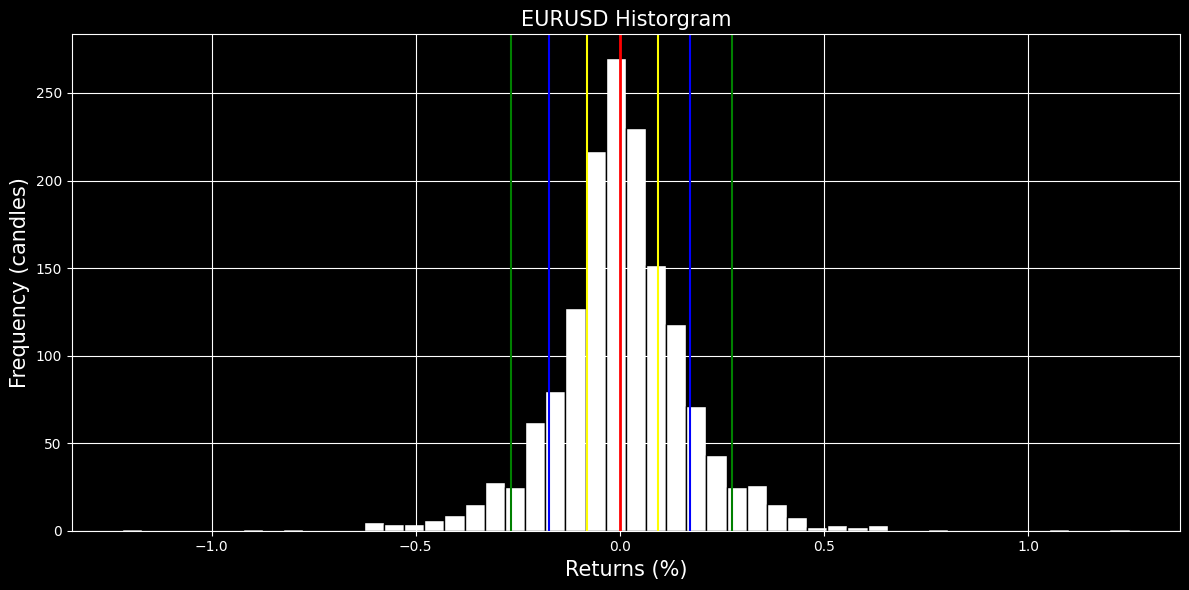

In [27]:
# HISTOGRAM
plt.figure(figsize=(12, 6))
plt.style.use('dark_background')
plt.hist(df_eurusd['Return'], bins=50, color='white', edgecolor='black')

plt.axvline(0, color='red', linestyle='-', linewidth=2)
plt.axvline(stats['std'], color='blue')
plt.axvline(-stats['std'], color='blue')

plt.axvline(percentiles['p05'], color='green')
plt.axvline(percentiles['p25'], color='yellow')
plt.axvline(percentiles['p75'], color='yellow')
plt.axvline(percentiles['p95'], color='green')

plt.title('EURUSD Historgram', fontsize=15)
plt.ylabel('Frequency (candles)', fontsize=15)
plt.xlabel('Returns (%)', fontsize=15)

plt.tight_layout()
plt.grid(True)
plt.show()

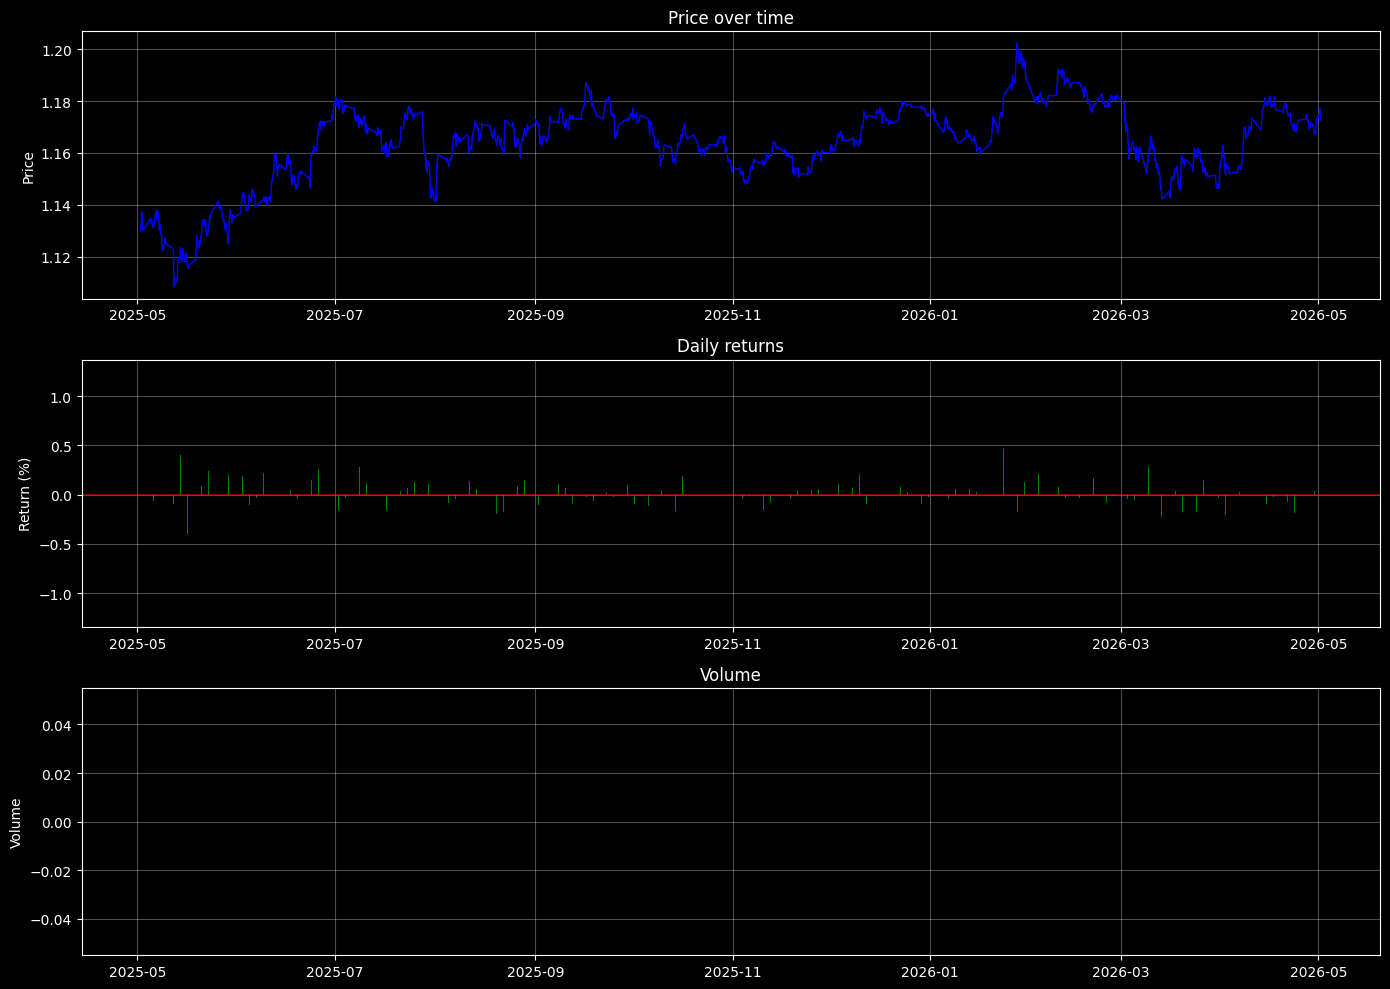

In [28]:
# TIME SERIES 
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

#Price
axes[0].plot(df_eurusd.index, df_eurusd['Close'], color='blue', linewidth=1)
axes[0].set_title('Price over time')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('Price')

# RETURNS
axes[1].bar(df_eurusd.index, df_eurusd['Return'], color='green', alpha=1, width=0.02)
axes[1].axhline(y=0, color='red', linestyle='-', alpha=0.5)
axes[1].set_title('Daily returns')
axes[1].set_ylabel('Return (%)')
axes[1].grid(True, alpha=0.3)

# VOLUME
axes[2].bar(df_eurusd.index, df_eurusd['Volume'], color='orange', alpha=0.6, width=0.02)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylabel('Volume')
axes[2].set_title('Volume')

plt.tight_layout()
plt.show()

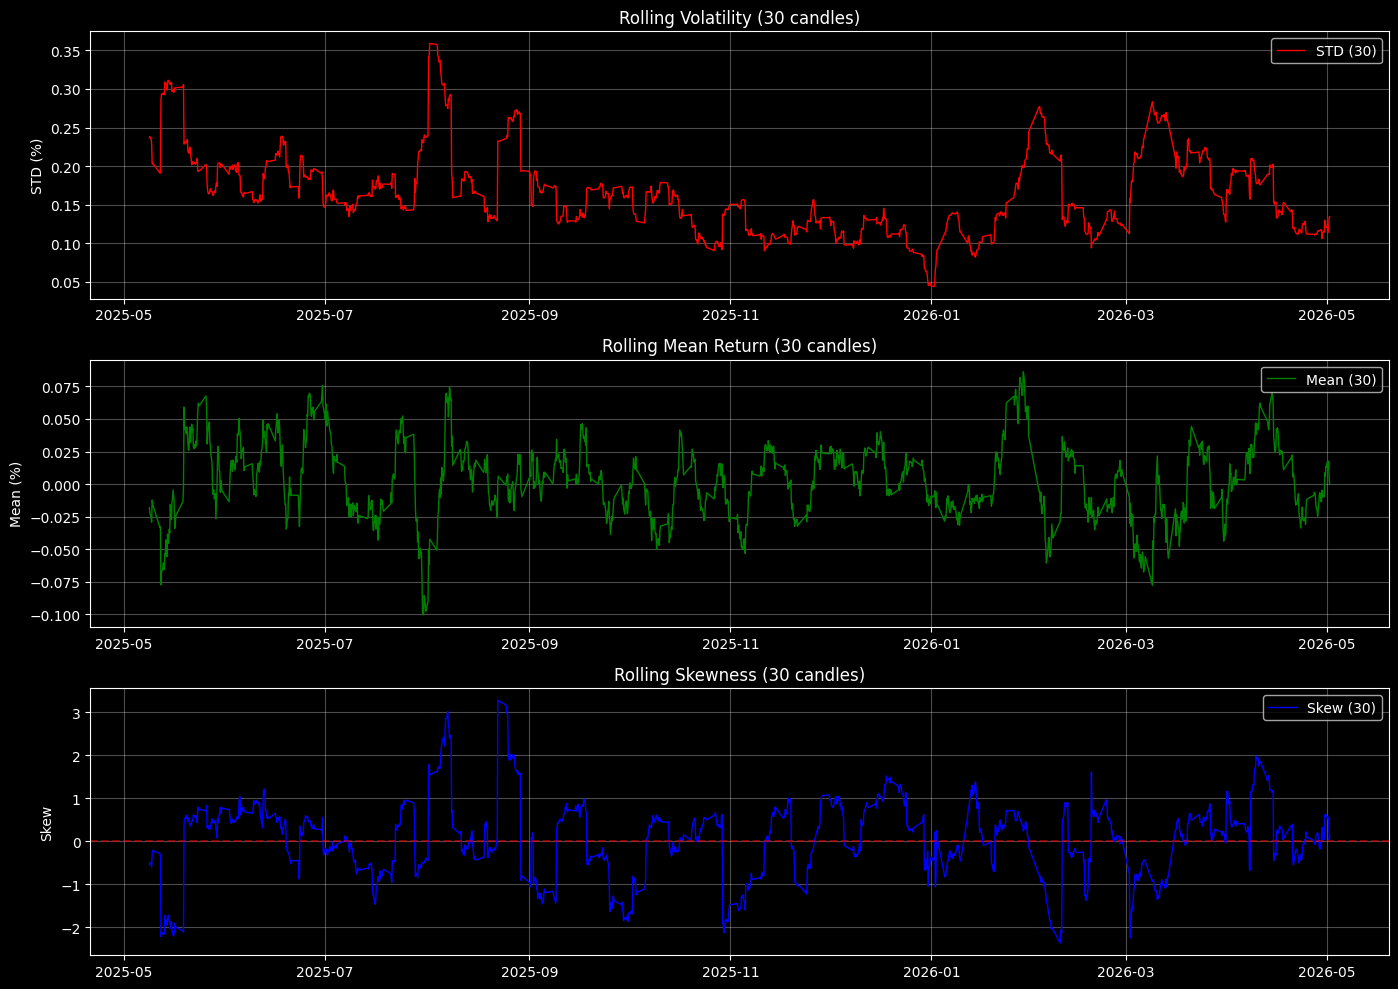

In [29]:
# ROLLING STATISTICS
df_eurusd['std_30'] = df_eurusd['Return'].rolling(30).std()
df_eurusd['mean_30'] = df_eurusd['Return'].rolling(30).mean()
df_eurusd['skew_30'] = df_eurusd['Return'].rolling(30).skew()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# STD
axes[0].plot(df_eurusd.index, df_eurusd['std_30'], color='red', linewidth=1, label='STD (30)')
axes[0].set_title('Rolling Volatility (30 candles)')
axes[0].set_ylabel('STD (%)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# MEAN
axes[1].plot(df_eurusd.index, df_eurusd['mean_30'], color='green', linewidth=1, label='Mean (30)')
axes[1].set_title('Rolling Mean Return (30 candles)')
axes[1].set_ylabel('Mean (%)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# SKEW
axes[2].plot(df_eurusd.index, df_eurusd['skew_30'], color='blue', linewidth=1, label='Skew (30)')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('Rolling Skewness (30 candles)')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylabel('Skew')
axes[2].legend()

plt.tight_layout()
plt.show()

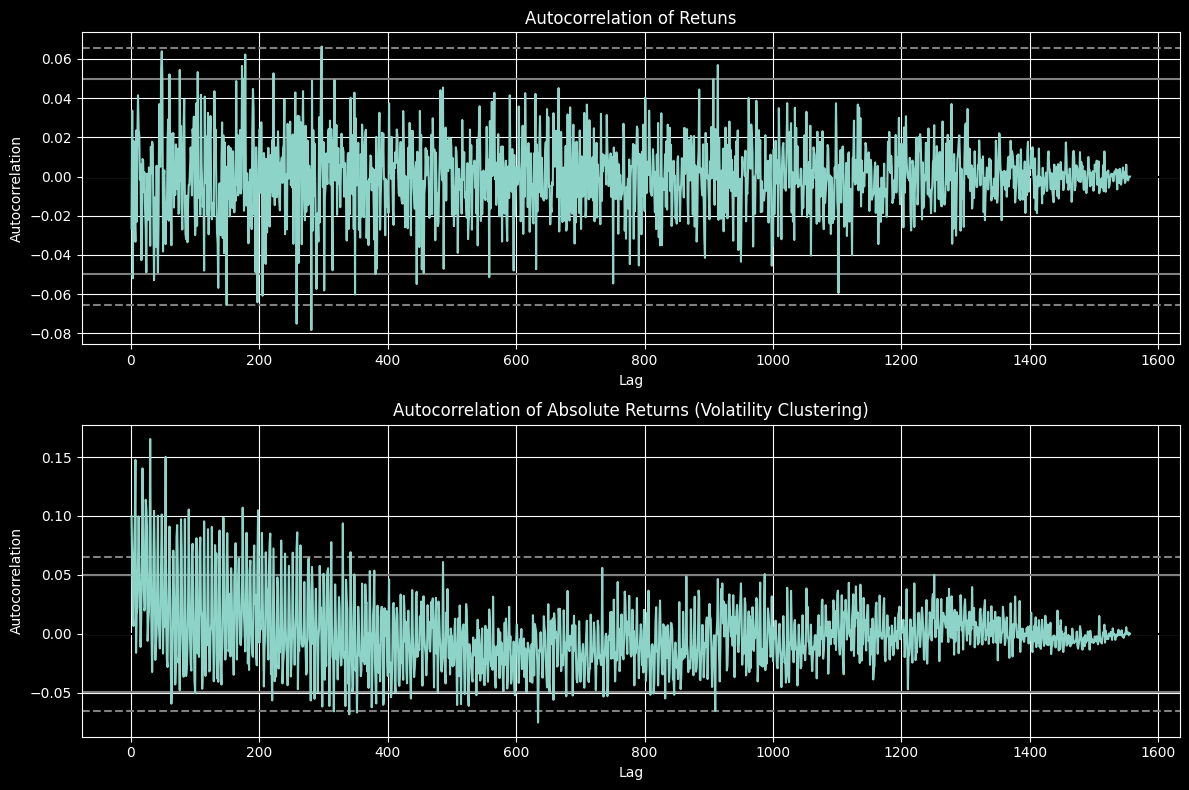

In [30]:
# AUTOCORRELATION

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# RETURNS AUTOCORRELATION
autocorrelation_plot(df_eurusd['Return'], ax=axes[0])
axes[0].set_title('Autocorrelation of Retuns')
axes[0].set_ylabel('Autocorrelation')

#  ABSOLUTE RETURNS AUTOCORRELATION (VOLATILITY CLUSTERING)
autocorrelation_plot(df_eurusd['Return'].abs(), ax=axes[1])
axes[1].set_title('Autocorrelation of Absolute Returns (Volatility Clustering)')
axes[1].set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

In [31]:
"""
viendo los datos que obtuvimos, gracias al skew puedo darme cuenta que el eurusd se mantuvo y no tuve ni perdidas ni ganancias significativas este ultimo año y 
lo podemos corroborar en el histograma viendo que la campana esta casi perfecta, viendo el  std que esta en 0.173 puedo saber que los movimientos no son muy fuertes 
osea que  no hay tanta volatilidad en general, pero algo me gnera duda: tengo entendido que el kurt promedio es de 3, en este caso muestra un valor de 5.8, con ese dato 
tendrian que haber bastantes movimientos bruscos, tal vez deberia comprobar. los percentiles tambien nos indican rangos bastante cortos, osea que los movimientos no son tan bruscos.
ahora veo los outliers y solo pasaron un 1.6% de veces, tal vez es una cantidad alta y por eso el kurt es alto, pero en realidad no se mucho de los outliers
en el histograma una campana bastante balanceada, casi perfecta como mencione antes, nada que sorprenda
en las time series se puede observar que el price over time ha sido positivo con pocas caidas significativas (3 fuertes se ven a simple vista). en el daily retuns vemos porcentajes bastante cortos
en las rolling statistics podemos ver que la volatilidad como mencione es bastante moderada, se puede ver movimientos fuertes pero si observmos el eje Y son porcentajes bastante cortos. la rolling
mean return, aplica casi lo mismo que la rolling volatility, se ven movimientos pero si se mira el eje Y no son movimientos significativos. el skwe si me parece raro ya que aca  si se puede ver
movimientos grandes y en el histograma pudimos ver que era casi perfecta, creo que hubo meses o semanas en los que el eurusd estuvo siguiendo una tendencia y no solo oscilando
viendo el primer grafico de autocorrelacion (autocorrelation of returns) se puede ver que las lineas estan dentro de las lineas punteadas, lo que nos indica que no podemos predecir el precio 
del siguiente dia con datos pasados, en cambio la segunda grafica (Autocorrelation of Absolute Returns (Volatility Clustering)) inicia con barras hacia el lado postivo saliendo de las lineas 
punteadas en lags cortos, eso me dijiste que nos indica que si hoy hay volatilidad el siguiente dia es muy probable que haya, con esto podriamos predecir la volatilidad y tomar decisiones. 
no siento que pueda proponer una estrategia aun, pero con lo que mencione tal vez podriammos apuntar a tomar ganancias cuando haya tendencias de volatilidad, recomendaria implementar un sistema 
de prediccion de volatilidad
"""

'\nviendo los datos que obtuvimos, gracias al skew puedo darme cuenta que el eurusd se mantuvo y no tuve ni perdidas ni ganancias significativas este ultimo año y \nlo podemos corroborar en el histograma viendo que la campana esta casi perfecta, viendo el  std que esta en 0.173 puedo saber que los movimientos no son muy fuertes \nosea que  no hay tanta volatilidad en general, pero algo me gnera duda: tengo entendido que el kurt promedio es de 3, en este caso muestra un valor de 5.8, con ese dato \ntendrian que haber bastantes movimientos bruscos, tal vez deberia comprobar. los percentiles tambien nos indican rangos bastante cortos, osea que los movimientos no son tan bruscos.\nahora veo los outliers y solo pasaron un 1.6% de veces, tal vez es una cantidad alta y por eso el kurt es alto, pero en realidad no se mucho de los outliers\nen el histograma una campana bastante balanceada, casi perfecta como mencione antes, nada que sorprenda\nen las time series se puede observar que el price o

In [32]:
# STRATEGY AND BACKTESTING
class Volatlity_breakout(Strategy):
    #VALUES
    sl_pct = 0.0015
    tp_pct = 0.003
    window = 30

    def init(self):
        close = self.data.Close
        self.rolling_std = self.I(lambda x: pd.Series(x).rolling(self.window).std(), close)

        volatility_values = pd.Series(close). rolling(self.window).std()
        self.volatility_thereshold = volatility_values.quantile(0.75)

    def next(self):
        price = self.data.Close[-1]

        if self.position:
            return
        
        if self.rolling_std[-1] > self.volatility_thereshold:
            self.open_long(price)

        if self.rolling_std < self.volatility_thereshold:
            self.closed_trades


    def open_long(self, price):
        self.buy(
            sl=price * (1 - self.sl_pct),
            tp=price * (1 + self.tp_pct)
        )

    def open_short(self, price):
        self.sell(
            sl=price * (1 + self.sl_pct),
            tp=price * (1 - self.tp_pct)
        )

In [33]:
#BACKTEST
bt = Backtest(df_eurusd, Volatlity_breakout, cash=100, commission=0.0001)
stats = bt.run()
print(stats)

Start                     2025-05-01 23:00...
End                       2026-05-01 19:00...
Duration                    364 days 20:00:00
Exposure Time [%]                    27.05656
Equity Final [$]                     98.37804
Equity Peak [$]                     100.94282
Commissions [$]                       3.51832
Return [%]                           -1.62196
Buy & Hold Return [%]                 4.34986
Return (Ann.) [%]                    -1.40134
Volatility (Ann.) [%]                 2.61483
CAGR [%]                             -1.12316
Sharpe Ratio                         -0.53592
Sortino Ratio                        -0.71987
Calmar Ratio                         -0.45636
Alpha [%]                             -2.5253
Beta                                  0.20767
Max. Drawdown [%]                    -3.07071
Avg. Drawdown [%]                    -1.16387
Max. Drawdown Duration      352 days 12:00:00
Avg. Drawdown Duration      118 days 02:00:00
# Trades                          

In [34]:
optimized = bt.optimize(
    sl_pct=[0.0005, 0.001, 0.0015],
    tp_pct=[0.002, 0.003, 0.005],
    window=[20, 40, 50, 60],
    maximize='Sharpe Ratio'
)

print(optimized)

Start                     2025-05-01 23:00...
End                       2026-05-01 19:00...
Duration                    364 days 20:00:00
Exposure Time [%]                    25.64267
Equity Final [$]                    100.51894
Equity Peak [$]                     101.23677
Commissions [$]                       2.26828
Return [%]                            0.51894
Buy & Hold Return [%]                 5.48715
Return (Ann.) [%]                      0.4477
Volatility (Ann.) [%]                 2.89671
CAGR [%]                              0.35816
Sharpe Ratio                          0.15455
Sortino Ratio                         0.22535
Calmar Ratio                          0.15787
Alpha [%]                             -0.8169
Beta                                  0.24345
Max. Drawdown [%]                    -2.83594
Avg. Drawdown [%]                    -1.06557
Max. Drawdown Duration      210 days 13:00:00
Avg. Drawdown Duration       50 days 12:00:00
# Trades                          